# xarrayrf: arrays that know where they are

Scientific arrays describe *somewhere*: a patient's head, a slide under a microscope, a patch of
the Earth, a region of spacetime. xarray keeps the labels; **xarrayrf keeps the place.**

Attach a reference frame to a `DataArray` once. From then on, ordinary xarray code (selection,
arithmetic, alignment, Datasets, saving to disk) carries it along, and anything that would put
data in the wrong place is refused instead of silently accepted. The same few ideas work for
medical images, microscopy, geospatial rasters and physics.

This notebook is a short tour on real, public data: microscopy and satellite images read
directly from public servers, and MRI downloaded once and cached. It needs a network connection.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tour_data  # fetches and caches the MRI study
import xarray as xr
from matplotlib.colors import ListedColormap

import xarrayrf as xrf
import xarrayrf.native  # registers the .rf accessor
from xarrayrf import dicom, geotiff, ngff, nifti

workdir = Path(tempfile.mkdtemp())
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Frame once, then just use xarray

A frame says *which* space the data lives in; a transform says how the array's own coordinates
map into it. Here a stained tissue section (colonic glands; FHL2 in brown, nuclei in blue) is
placed on a slide-scanner stage: 0.5 µm pixels, rotated 10° against the stage axes, at
(1200, 800) µm on the slide. The colour channels simply come along.

In [2]:
stage = xrf.ReferenceFrame.local(xrf.CoordinateSystem(("x", "y"), ("um", "um")))
angle, pixel = np.deg2rad(10), 0.5
placement = xrf.AffineTransform(
    source=xrf.ArrayCoordinates(("row", "column"), ("1", "1")),
    target=stage,
    target_axes=("x", "y"),
    basis_vectors={
        "row": (-np.sin(angle) * pixel, np.cos(angle) * pixel),
        "column": (np.cos(angle) * pixel, np.sin(angle) * pixel),
    },
    translation=[1200.0, 800.0],
)
pixels = plt.imread(tour_data.tissue_section())[..., :3]
image = xr.DataArray(
    pixels,
    dims=("row", "column", "rgb"),
    name="section",
    coords={"row": np.arange(512), "column": np.arange(512), "rgb": ["red", "green", "blue"]},
).rf.frame(placement, dims=("row", "column"))
image

<xarray.DataArray 'section' (row: 512, column: 512, rgb: 3)> Size: 3MB
array([[[0.6117647 , 0.4627451 , 0.31764707],
        [0.6392157 , 0.49019608, 0.34509805],
        [0.6117647 , 0.45490196, 0.31764707],
        ...,
        [0.59607846, 0.627451  , 0.76862746],
        [0.6627451 , 0.6862745 , 0.8117647 ],
        [0.7411765 , 0.76862746, 0.88235295]],

       [[0.5529412 , 0.4117647 , 0.27058825],
        [0.5647059 , 0.42352942, 0.28235295],
        [0.5529412 , 0.4       , 0.27058825],
        ...,
        [0.6431373 , 0.6745098 , 0.8156863 ],
        [0.654902  , 0.6784314 , 0.8039216 ],
        [0.6862745 , 0.7137255 , 0.8235294 ]],

       [[0.49019608, 0.36078432, 0.23137255],
        [0.5176471 , 0.3882353 , 0.25882354],
        [0.5411765 , 0.40392157, 0.2784314 ],
        ...,
...
        [0.83137256, 0.827451  , 0.8117647 ],
        [0.8392157 , 0.8235294 , 0.8117647 ],
        [0.8509804 , 0.8352941 , 0.8235294 ]],

       [[0.8509804 , 0.8392157 , 0.8117647 ],
        [0.87058824, 0.85882354, 0.83137256],
        [0.9019608 , 0.8901961 , 0.8627451 ],
        ...,
        [0.8392157 , 0.8352941 , 0.827451  ],
        [0.827451  , 0.8117647 , 0.8       ],
        [0.84313726, 0.8235294 , 0.8117647 ]],

       [[0.87058824, 0.85882354, 0.83137256],
        [0.87058824, 0.85882354, 0.83137256],
        [0.8784314 , 0.8666667 , 0.8392157 ],
        ...,
        [0.8235294 , 0.81960785, 0.8117647 ],
        [0.8235294 , 0.8039216 , 0.7921569 ],
        [0.84313726, 0.8235294 , 0.8117647 ]]],
      shape=(512, 512, 3), dtype=float32)
Coordinates:
  * row      (row) int64 4kB 0 1 2 3 4 5 6 7 ... 504 505 506 507 508 509 510 511
  * column   (column) int64 4kB 0 1 2 3 4 5 6 7 ... 505 506 507 508 509 510 511
  * rgb      (rgb) <U5 60B 'red' 'green' 'blue'
Indexes:
  ┌ row      BindingIndex
  └ column

Now treat it as any other `DataArray`: adjust the contrast, crop it, keep every second pixel.
The result is a different, smaller array, but every sample still knows exactly where it is.

In [3]:
view = (image**0.6).isel(row=slice(120, 380, 2), column=slice(200, 460, 2))

print("view:", dict(view.sizes))
print(
    "its first pixel sits at   ", view.rf.geometry.point_at(row=0, column=0).values.round(2), "µm"
)
print(
    "original pixel (120, 200) at",
    image.rf.geometry.point_at(row=120, column=200).values.round(2),
    "µm",
)

view: {'row': 130, 'column': 130, 'rgb': 3}
its first pixel sits at    [1288.06  876.45] µm
original pixel (120, 200) at [1288.06  876.45] µm


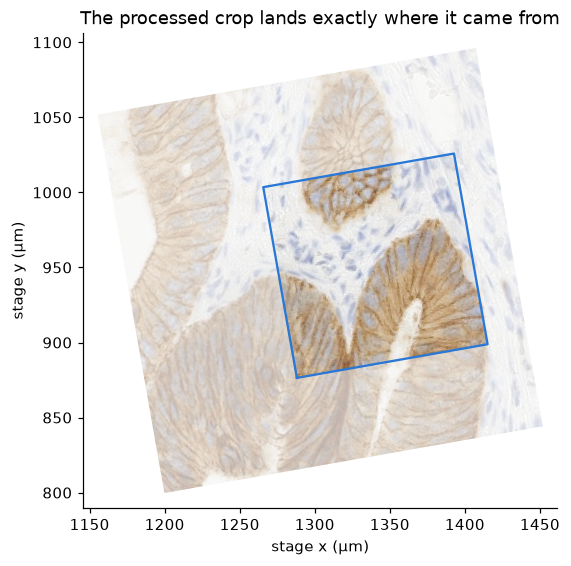

In [4]:
from matplotlib.transforms import Affine2D


def place(ax, array, **style):
    """Draw an RGB array at its stage position, using its own geometry."""
    to_stage = Affine2D(array.rf.geometry.lattice(("column", "row")).affine)
    rows, columns = array.sizes["row"], array.sizes["column"]
    ax.imshow(
        np.clip(array.transpose("row", "column", "rgb").values, 0, 1),
        extent=(-0.5, columns - 0.5, rows - 0.5, -0.5),
        transform=to_stage + ax.transData,
        **style,
    )
    corners = np.array([[0, 0], [0, columns - 1], [rows - 1, columns - 1], [rows - 1, 0], [0, 0]])
    return array.rf.geometry.lattice().transform_point(corners)


fig, ax = plt.subplots(figsize=(6, 5.6))
outline = place(ax, image, alpha=0.35)
crop = place(ax, view)
ax.plot(*crop.T, color=BLUE, lw=1.5)
ax.set(
    xlim=(outline[:, 0].min() - 10, outline[:, 0].max() + 10),
    ylim=(outline[:, 1].min() - 10, outline[:, 1].max() + 10),
    aspect="equal",
    xlabel="stage x (µm)",
    ylabel="stage y (µm)",
    title="The processed crop lands exactly where it came from",
)
plt.show()

<sub>Image: scikit-image `immunohistochemistry` sample (Center for Microscopy and Molecular
Imaging), no known copyright restrictions. The stage placement is illustrative.</sub>

## 2. Guardrails, not handcuffs

Frames carry identity. Combining arrays from different frames is refused, because their pixels
do not describe the same places. Plain arrays are still welcome, and when you *know* two frames
are the same space, one explicit call says so.

In [5]:
elsewhere = xrf.ReferenceFrame.local(stage.coordinate_system)  # another slide, same axes
other = image.rf.unframe().rf.frame(
    xrf.AffineTransform.from_matrix(
        source=placement.source,
        target=elsewhere,
        matrix=placement.matrix,
        translation=placement.translation,
    ),
    dims=("row", "column"),
)

try:
    image + other
except ValueError as error:
    print("refused:", error)

mask = xr.ones_like(image.rf.unframe())  # a plain DataArray, same labels
print("framed + plain stays framed:", (image * mask).rf.is_framed)
print("after an explicit assumption:", (image + other.rf.assume_frame(image)).rf.is_framed)

refused: incompatible framed coordinate mappings: the operands are in different reference frames (xarrayrf.local:55755a43747245e9b8446fc3167b8f3c and xarrayrf.local:50885c7118bd452b86c3a4fbfab3d008); resample one onto the other with a transform between the frames, or use rf.assume_frame if they are the same space
framed + plain stays framed: True
after an explicit assumption: True


## 3. Microscopy: a public OME-Zarr image, opened over the web

A confocal volume of mouse tissue from the Image Data Resource (IDR), stored as OME-Zarr on a
public server: two channels (Lamin B1 marking the nuclear envelope, DAPI marking DNA),
236 planes, calibrated in micrometres. Opening it reads only metadata.

In [6]:
IDR_TISSUE = "https://uk1s3.embassy.ebi.ac.uk/idr/zarr/v0.4/idr0062A/6001240.zarr"
tissue = ngff.open(IDR_TISSUE)
lattice = tissue.rf.geometry.lattice()
print(dict(tissue.sizes), "| lazy:", type(tissue.data).__name__)
print("voxel size (z, y, x):", lattice.spacing.round(3), "µm")

{'c': 2, 'z': 236, 'y': 275, 'x': 271} | lazy: Array
voxel size (z, y, x): [0.5  0.36 0.36] µm


Select a plane and it knows its depth; only that plane's chunks are downloaded.

In [7]:
plane = tissue.isel(z=118).compute()
print("plane z = 118 sits at depth", plane.rf.geometry.point_at(y=0, x=0).values[0].round(2), "µm")

plane z = 118 sits at depth 59.02 µm


OME-Zarr stores several resolution levels. They share one frame but sample it differently,
so combining them naively is refused, and `resample_to` brings one onto the other.

In [8]:
coarse = ngff.open(IDR_TISSUE, level="1")  # 2x downsampled in y and x
print("levels:", dict(tissue.sizes), "and", dict(coarse.sizes))
try:
    tissue + coarse
except ValueError as error:
    print("refused:", error)

slab = dict(z=slice(110, 127))
upsampled = coarse.isel(slab).rf.resample_to(tissue.isel(slab)).compute()

levels: {'c': 2, 'z': 236, 'y': 275, 'x': 271} and {'c': 2, 'z': 236, 'y': 137, 'x': 135}
refused: incompatible framed coordinate mappings: the operands sample the same frame on different grids; resample one onto the other with rf.resample_to


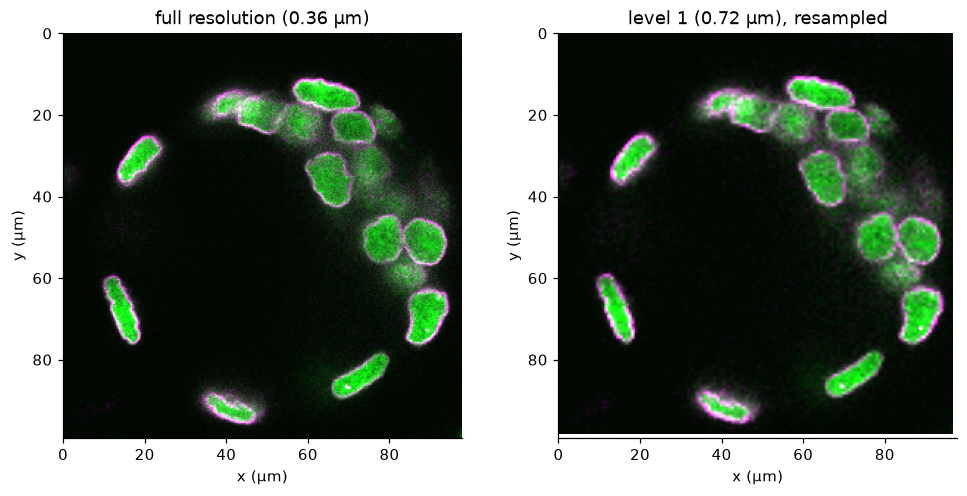

In [9]:
def composite(image):
    """Lamin B1 in magenta, DAPI in green, each scaled to its 99.5th percentile."""
    lamin, dapi = (np.clip(image.isel(c=c) / image.isel(c=c).quantile(0.995), 0, 1) for c in (0, 1))
    return np.stack([lamin, dapi, lamin], axis=-1)


height, width = plane.sizes["y"] * lattice.spacing[1], plane.sizes["x"] * lattice.spacing[2]
extent = [0, float(width), float(height), 0]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4), constrained_layout=True)
panels = [
    (plane, "full resolution (0.36 µm)"),
    (upsampled.isel(z=8), "level 1 (0.72 µm), resampled"),
]
for ax, (shown, title) in zip(axes, panels, strict=True):
    ax.imshow(composite(shown), extent=extent)
    ax.set(title=title, xlabel="x (µm)", ylabel="y (µm)")
plt.show()

**In napari**, the same geometry places the layer in micrometres; no manual `scale` or
`translate`:

```python
import napari

viewer = napari.Viewer()
viewer.add_image(tissue.data, channel_axis=0, name=["Lamin B1", "DAPI"],
                 colormap=["magenta", "green"], affine=lattice.affine)
```

<sub>Data: IDR idr0062 (Blin et al., *PLOS Biology* 2019), CC BY 4.0.</sub>

## 4. Medical imaging: one study, three orientations, two formats

Fetal MRI is acquired as quick single-shot series in several orientations. Here are three T2
HASTE series (coronal, sagittal, axial) of a pregnant non-human primate from one session, as
DICOM, plus the same series converted to NIfTI with `dcm2niix`. The files are de-identified and
downloaded once (about 29 MB, CC BY 4.0). Readers are lazy: no pixels are read until needed.

In [10]:
study_dir = tour_data.mri_study()
coronal = dicom.open(study_dir / "dicom" / "t2_haste_cor_pat2")
sagittal = dicom.open(study_dir / "dicom" / "t2_haste_sag_pat2")
axial = dicom.open(study_dir / "dicom" / "t2_haste_axial_pat2")

for name, series in [("coronal", coronal), ("sagittal", sagittal), ("axial", axial)]:
    print(f"{name:9s}", dict(series.sizes))
print(
    "one patient space:",
    coronal.rf.reference_frame == sagittal.rf.reference_frame == axial.rf.reference_frame,
)

coronal   {'k': 84, 'j': 320, 'i': 160}
sagittal  {'k': 80, 'j': 320, 'i': 160}
axial     {'k': 72, 'j': 160, 'i': 320}
one patient space: True


Three differently oriented grids, one frame. `resample_to` puts the sagittal and axial series
onto the coronal grid; the results are framed in the coronal geometry and line up anatomically.
They differ where they should: different moments, 2 mm slices, and a fetus that moves.

In [11]:
sagittal_on_coronal = sagittal.rf.resample_to(coronal).compute()  # lazy until computed
axial_on_coronal = axial.rf.resample_to(coronal).compute()

views = xr.Dataset(
    {"coronal": coronal.compute(), "sagittal": sagittal_on_coronal, "axial": axial_on_coronal}
)
views["average"] = views.to_dataarray("view").mean("view", skipna=True)
print({name: views[name].rf.is_framed for name in views.data_vars})

{'coronal': True, 'sagittal': True, 'axial': True, 'average': True}


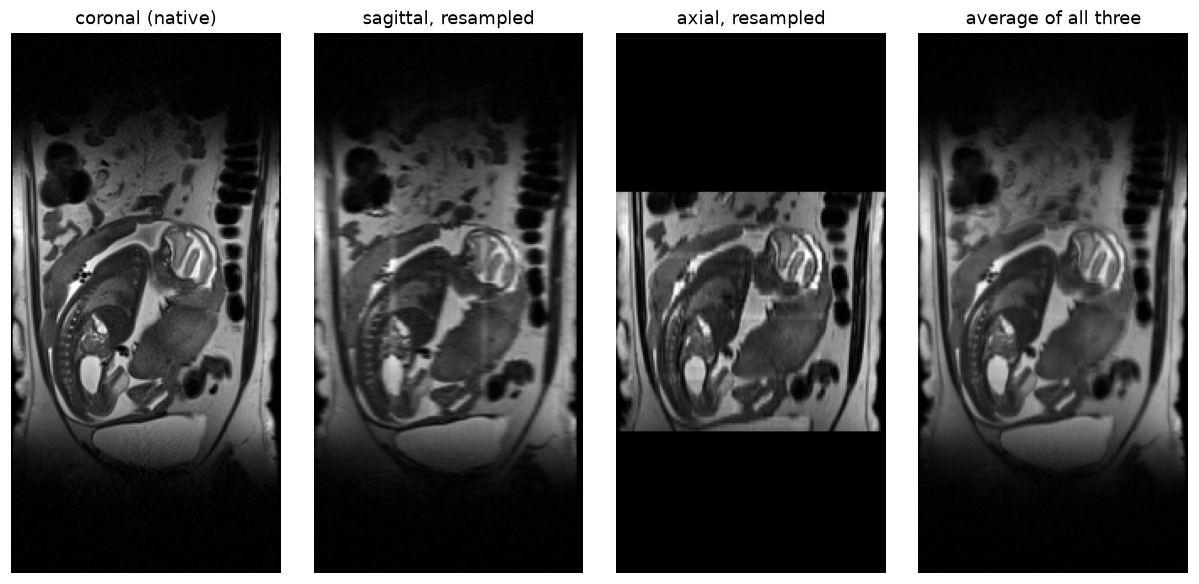

In [12]:
gray = plt.get_cmap("gray").with_extremes(bad="black")
fig, axes = plt.subplots(1, 4, figsize=(11, 5.2), constrained_layout=True)
middle = dict(k=42)
top = float(views.coronal.quantile(0.995))
titles = {
    "coronal": "coronal (native)",
    "sagittal": "sagittal, resampled",
    "axial": "axial, resampled",
    "average": "average of all three",
}
for ax, (name, title) in zip(axes, titles.items(), strict=True):
    ax.imshow(views[name].isel(middle), cmap=gray, vmin=0, vmax=top)
    ax.set_title(title)
    ax.set_axis_off()
plt.show()

The NIfTI files were written by a different tool, in RAS rather than LPS, with a different
array layout. NIfTI carries no study identifier, so its frame is **anonymous**: usable on its own,
but never assumed to be the DICOM patient space, and the refusal says what to do.

In [13]:
unnamed = nifti.open(study_dir / "nifti" / "t2_haste_cor.nii.gz")
print("anonymous frame:", unnamed.rf.reference_frame.is_anonymous)
try:
    unnamed.rf.resample_to(coronal)
except ValueError as error:
    print("refused:", error)

anonymous frame: True
refused: different reference frames; source operand is anonymous; the grids differ; assert the shared world with frame= or rf.assume_frame, then use rf.resample_to


We know it is the same session, so we say so when opening it (`rf.assume_frame` would do the
same afterwards). The RAS-to-LPS conversion is derived automatically, and the NIfTI volume then
drops onto the DICOM grid, agreeing to within `dcm2niix`'s single-precision affine.

In [14]:
coronal_nifti = nifti.open(study_dir / "nifti" / "t2_haste_cor.nii.gz", frame=coronal)
print("NIfTI layout:", dict(coronal_nifti.sizes), "  DICOM layout:", dict(coronal.sizes))

difference = coronal_nifti.rf.resample_to(coronal) - views.coronal
print(
    f"largest difference: {float(abs(difference).max()):.2f} on a signal up to {int(views.coronal.max())}"
)

NIfTI layout: {'i': 160, 'j': 320, 'k': 84}   DICOM layout: {'k': 84, 'j': 320, 'i': 160}


largest difference: 0.18 on a signal up to 4038


## 5. Reformat to a standard plane

Each series knows its orientation: the direction each array index increases toward, in patient
letters. DICOM's `SliceThickness` is kept as each slice's declared extent (its *cell*), separately
from the spacing between slices. In this study the two are equal; for gapped or overlapping
slices they differ, and the cells-domain queries and resampling respect the declared extent.

In [15]:
from xarrayrf import anatomy

for name, series in [("coronal", coronal), ("sagittal", sagittal), ("axial", axial)]:
    grid = series.rf.grid  # the sampling, without pixels
    spacing = float(series.rf.geometry.lattice().spacing[0])  # mm between slice centres
    lo, hi = grid.intervals["k"][0]  # declared cell of the first slice, in index units
    print(
        f"{name:9s} {anatomy.orientation_codes(grid)}  slices {spacing:.1f} mm apart, "
        f"{(hi - lo) * spacing:.1f} mm thick"
    )

coronal   PIL  slices 2.0 mm apart, 2.0 mm thick
sagittal  RIP  slices 2.0 mm apart, 2.0 mm thick
axial     SPL  slices 2.0 mm apart, 2.0 mm thick


`cardinal_grid` builds an axial target in the same patient space, covering every cell of the
coronal series at 1 mm. Resampling both the coronal and the native axial series onto it
reformats one and re-grids the other. The target covers cells, so resample in the cells domain to
fill its edges.

axial target: {'j': 321, 'k': 169, 'i': 160} SPL


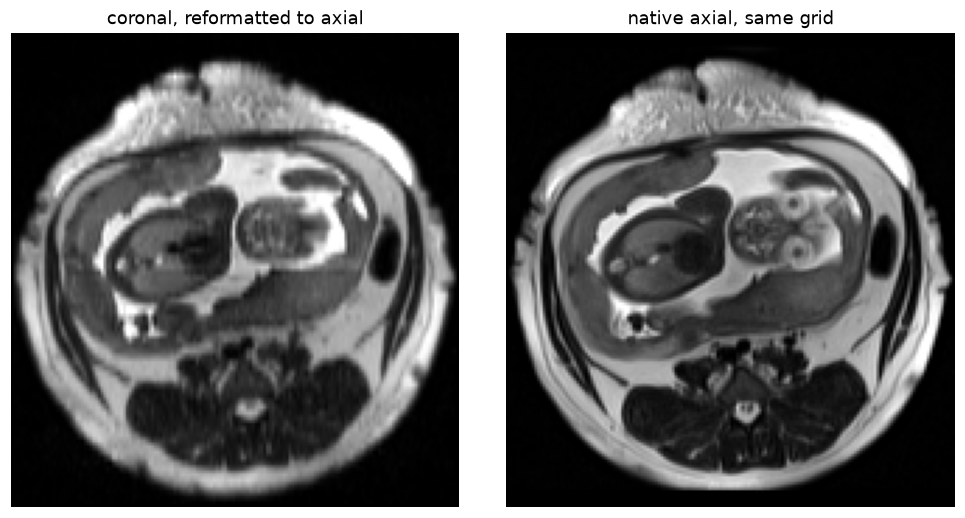

In [16]:
target = anatomy.cardinal_grid(coronal.rf.grid, "axial", spacing=1.0)
print("axial target:", dict(target.sizes), anatomy.orientation_codes(target))

from_coronal = coronal.rf.resample_to(target, domain="cells").compute()
from_axial = axial.rf.resample_to(target, domain="cells").compute()

slice_dim = target.dims[0]  # the dimension pointing toward S
cut = {slice_dim: target.sizes[slice_dim] // 2}
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), constrained_layout=True)
for ax, (title, array) in zip(
    axes,
    [("coronal, reformatted to axial", from_coronal), ("native axial, same grid", from_axial)],
    strict=True,
):
    ax.imshow(array.isel(cut), cmap=gray, vmin=0, vmax=top)
    ax.set_title(title)
    ax.set_axis_off()
plt.show()

## 6. Ask where things are

Every framed array answers geometric questions in patient space. Pick a voxel in the coronal
series, ask where it is in millimetres, then ask which voxel of the *native* sagittal and axial
series sits at that same place, without resampling anything.

In [17]:
voxel = dict(k=42, j=150, i=80)
point = coronal.rf.geometry.point_at(**voxel)
print("coronal voxel", voxel, "is at", point.round(1).values, "mm (LPS)")
for name, series in [("sagittal", sagittal), ("axial", axial)]:
    position = series.rf.geometry.positions_at(point.values)
    located = ", ".join(
        f"{dim}={value:.1f}" for dim, value in zip(series.rf.geometry_dims, position, strict=True)
    )
    print(f"  in the native {name} series it is voxel ({located})")

coronal voxel {'k': 42, 'j': 150, 'i': 80} is at [ -1. -65.  10.] mm (LPS)
  in the native sagittal series it is voxel (k=37.8, j=151.0, i=76.2)
  in the native axial series it is voxel (k=43.0, j=81.0, i=159.0)


## 7. Brain atlases: a subject in MNI space

A T1-weighted MRI from a public study (OpenNeuro ds000001) lives in its own scanner space, an
anonymous frame because the file does not name it. The
MNI152 template and the Schaefer 2018 parcellation are NIfTI files coded as MNI space, so they
share one frame automatically, without any registration between them.

In [18]:
brain = tour_data.brain_images()
subject = nifti.open(brain / "sub-01_T1w.nii.gz")
template = nifti.open(brain / "MNI152NLin2009cAsym_T1w.nii.gz")
atlas = nifti.open(brain / "Schaefer2018_100Parcels7Networks.nii.gz")

print("subject frame:", subject.rf.reference_frame.identifier[0], dict(subject.sizes))
print(
    "template and atlas:",
    template.rf.reference_frame.identifier,
    "shared:",
    template.rf.reference_frame == atlas.rf.reference_frame,
)

subject frame: xarrayrf.anonymous {'i': 160, 'j': 192, 'k': 192}
template and atlas: ('nifti-template', 'MNI152') shared: True


A registration tool (here SimpleITK, see `tools/register_tour_subject.py`) produces an
affine between the two spaces. In xarrayrf it becomes a transform that names both frames, and
`resample_to` uses it to put the subject on the template's grid.

In [19]:
mni_to_subject = xrf.AffineTransform.from_matrix(
    source=template.rf.reference_frame,
    target=subject.rf.reference_frame,
    matrix=tour_data.MNI_TO_SUBJECT_MATRIX,
    translation=tour_data.MNI_TO_SUBJECT_TRANSLATION,
)
in_mni = subject.rf.resample_to(template, transform=mni_to_subject).compute()
print("subject now on the template grid:", dict(in_mni.sizes), in_mni.rf.reference_frame.identifier)

subject now on the template grid: {'i': 193, 'j': 229, 'k': 193} ('nifti-template', 'MNI152')


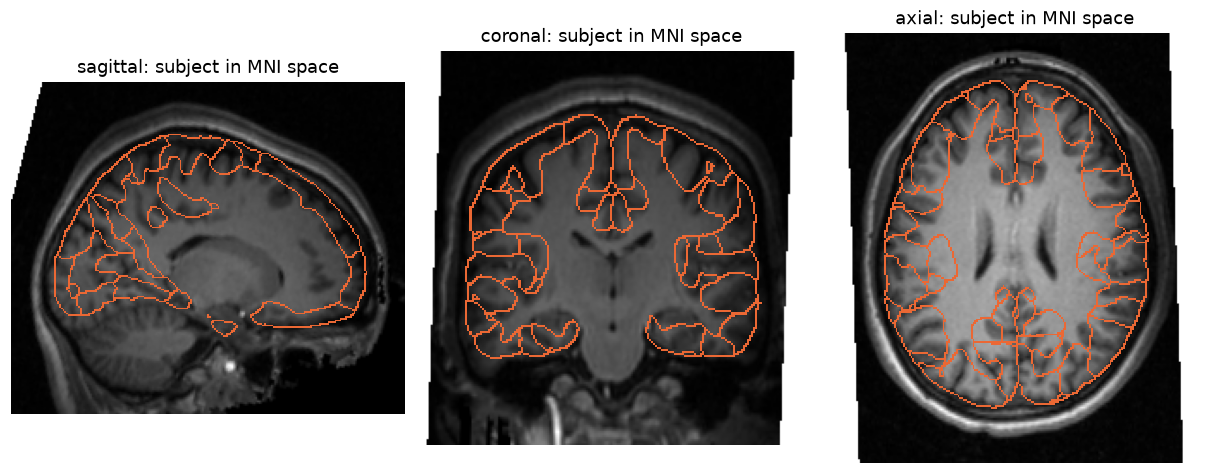

In [20]:
def boundaries(labels):
    """Pixels where the parcel label changes, as a transparent overlay."""
    edge = np.zeros(labels.shape, bool)
    edge[1:, :] |= labels[1:, :] != labels[:-1, :]
    edge[:, 1:] |= labels[:, 1:] != labels[:, :-1]
    return np.ma.masked_where(~edge, edge)


fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), constrained_layout=True)
for ax, (cut, title) in zip(
    axes, [(dict(i=80), "sagittal"), (dict(j=110), "coronal"), (dict(k=100), "axial")], strict=True
):
    ax.imshow(in_mni.isel(cut).values.T, cmap="gray", origin="lower")
    ax.imshow(
        boundaries(atlas.isel(cut).values.T),
        cmap=ListedColormap([ORANGE]),
        origin="lower",
        interpolation="none",
    )
    ax.set_title(f"{title}: subject in MNI space")
    ax.set_axis_off()
plt.show()

Ask the atlas about a voxel of the original scan: map it through the registration into MNI
space and look it up.

In [21]:
networks = pd.read_csv(brain / "Schaefer2018_100Parcels7Networks.tsv", sep="\t").set_index("index")[
    "name"
]

voxel = dict(i=69, j=33, k=84)
in_scanner = subject.rf.geometry.point_at(**voxel).values
in_template = mni_to_subject.inverse().transform_point([in_scanner])[0]
position = np.round(atlas.rf.geometry.positions_at(in_template)).astype(int)
parcel = int(atlas.isel(dict(zip(atlas.rf.geometry_dims, position, strict=True))))
print(f"subject voxel {voxel} -> MNI {in_template.round(1)} mm -> {networks[parcel]}")

subject voxel {'i': 69, 'j': 33, 'k': 84} -> MNI [-10.  -92.6   2.5] mm -> 7Networks_LH_Vis_5


A transform records which frames it connects, so it cannot be applied to the wrong data by
mistake: sub-01's registration is refused for sub-02, whose scan sits in its own space.

In [22]:
other_subject = nifti.open(brain / "sub-02_T1w.nii.gz")
try:
    other_subject.rf.resample_to(template, transform=mni_to_subject)
except ValueError as error:
    print("refused:", error)

refused: the transform maps nifti-template:MNI152 to xarrayrf.anonymous:cfeffab166654086a02792e905bea186, but this resampling needs nifti-template:MNI152 (target) to xarrayrf.anonymous:c2bf6733f98b47d3b3704808b04fdb0a (source); a transform applies only to the frames it was computed between


<sub>Data: OpenNeuro ds000001 (CC0); MNI152NLin2009cAsym template, © 1993–2004 Louis Collins,
McConnell Brain Imaging Centre, MNI, McGill University; Schaefer et al. 2018 parcellation, via
TemplateFlow.</sub>

## 8. Satellite imagery: public Sentinel-2 scenes

True-colour Sentinel-2 images (10 m pixels, 10 980 × 10 980 each) are public Cloud-Optimized
GeoTIFFs. Three scenes from one satellite pass over northern Italy: two neighbouring tiles in
UTM zone 32, and one covering the same ground from zone 33.

In [23]:
SCENE = (
    "https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/"
    "{zone}/T/{tile}/2023/8/S2A_{zone}T{tile}_20230821_0_L2A/TCI.tif"
)
west = geotiff.open(SCENE.format(zone=32, tile="PR"))
east = geotiff.open(SCENE.format(zone=32, tile="QR"))
next_zone = geotiff.open(SCENE.format(zone=33, tile="UL"))
print(
    dict(east.sizes),
    "| frames:",
    west.rf.reference_frame.identifier,
    east.rf.reference_frame.identifier,
    next_zone.rf.reference_frame.identifier,
)

{'band': 3, 'row': 10980, 'column': 10980} | frames: ('epsg', '32632') ('epsg', '32632') ('epsg', '32633')


Neighbouring tiles in one CRS share a frame. Define a new 15 km canvas directly in UTM
coordinates, straddling the seam between the tiles, and paint both onto it; only the few
internal tiles under the canvas are fetched.

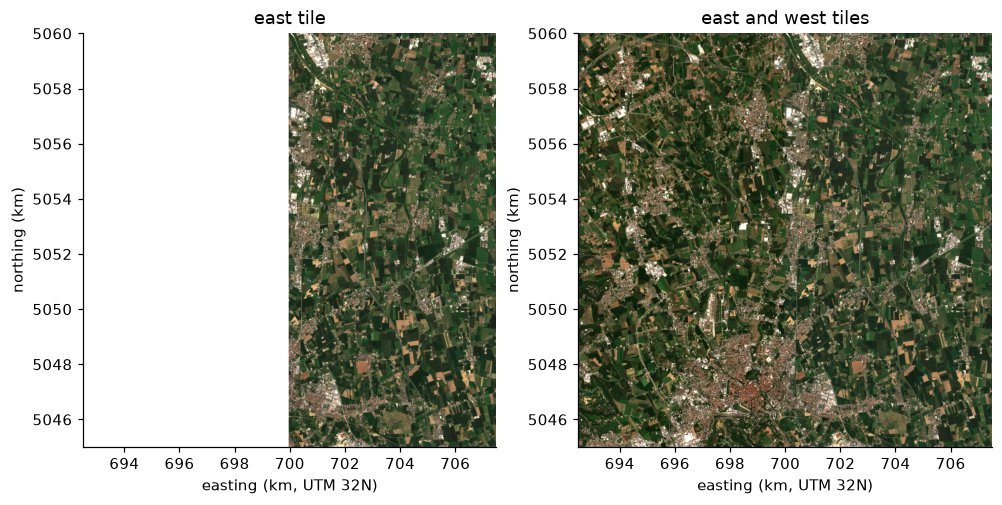

In [24]:
utm32 = east.rf.reference_frame
easting = 692_505.0 + 10.0 * np.arange(1500)  # metres, 10 m pixels
northing = 5_060_005.0 - 10.0 * np.arange(1500)
canvas = xr.DataArray(
    np.zeros((1500, 1500), np.uint8),
    dims=("northing", "easting"),
    coords={"easting": easting, "northing": northing},
).rf.frame(
    xrf.AffineTransform.from_matrix(
        source=xrf.ArrayCoordinates(("easting", "northing"), ("m", "m")),
        target=utm32,
        matrix=np.eye(2),
        translation=[0.0, 0.0],
    ),
    dims=("northing", "easting"),
)

east_only = east.rf.resample_to(canvas, method="nearest").compute()
mosaic = east_only.combine_first(west.rf.resample_to(canvas, method="nearest"))

extent = [easting[0] / 1e3, easting[-1] / 1e3, northing[-1] / 1e3, northing[0] / 1e3]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6), constrained_layout=True)
for ax, (shown, title) in zip(
    axes, [(east_only, "east tile"), (mosaic, "east and west tiles")], strict=True
):
    rgb = shown.transpose("northing", "easting", "band").values
    ax.imshow(np.nan_to_num(rgb, nan=255).astype(np.uint8), extent=extent)
    ax.set(title=title, xlabel="easting (km, UTM 32N)", ylabel="northing (km)")
plt.show()

The zone-33 scene covers the same ground in a different projection. Mixing them is refused;
reprojecting between UTM zones needs a nonlinear transform, which is on the roadmap.

In [25]:
try:
    east + next_zone
except ValueError as error:
    print("refused:", error)

refused: incompatible framed coordinate mappings: the operands are in different reference frames (epsg:32632 and epsg:32633); resample one onto the other with a transform between the frames, or use rf.assume_frame if they are the same space


The same situations in popular geospatial extensions (reproduced by
`tools/geo_failure_modes.py`):

| Operation | rioxarray 0.23 / rasterix 0.2 / xproj 0.2 | xarrayrf |
|---|---|---|
| Strided selection, then locate a pixel | wrong location (rioxarray) | correct |
| Add rasters in different CRSs | silently keeps one CRS (rioxarray) | refused |
| Join rasters | CRS lost; a missing CRS matches anything (rasterix) | frame kept |
| `join="override"` across CRSs | CRS rewritten (xproj) | refused |

<sub>Contains modified Copernicus Sentinel data 2023.</sub>

## 9. Physics: the same machinery in spacetime

Nothing above is specific to images. A reference frame can be an inertial frame and a transform a
Lorentz boost. Take an object of arbitrary shape, at rest in its own frame, and ask what a
laboratory observer measures at one instant while it flies past at 0.8 c. `resample_to` does the
work; relativity of simultaneity is handled by the geometry.

In [26]:
spacetime = xrf.CoordinateSystem(("ct", "x"), ("m", "m"))
rest = xrf.ReferenceFrame.declared(("demo", "object rest frame"), spacetime)
lab = xrf.ReferenceFrame.declared(("demo", "laboratory"), spacetime)
beta = 0.8
gamma = 1 / np.sqrt(1 - beta**2)
lab_to_rest = xrf.AffineTransform.from_matrix(
    source=lab,
    target=rest,
    translation=[0.0, 0.0],
    matrix=[[gamma, -gamma * beta], [-gamma * beta, gamma]],
)


def spacetime_grid(ct, x, frame):
    array = xr.DataArray(np.zeros((len(ct), len(x))), dims=("ct", "x"), coords={"ct": ct, "x": x})
    identity = xrf.AffineTransform.from_matrix(
        source=xrf.ArrayCoordinates(("ct", "x"), ("m", "m")),
        target=frame,
        matrix=np.eye(2),
        translation=[0.0, 0.0],
    )
    return array.rf.frame(identity, dims=("ct", "x"))


x_rest = np.linspace(-6, 6, 241)
shape = np.exp(-(((x_rest - 1.2) / 0.5) ** 2)) + 0.6 * np.exp(-(((x_rest + 1.5) / 0.9) ** 2))
obj = (
    spacetime_grid(np.linspace(-12, 12, 481), x_rest, rest) + shape
)  # at rest: same shape at every time
lab_now = spacetime_grid([0.0], np.linspace(-3.5, 3.5, 281), lab)  # the lab's instant ct = 0

measured = obj.rf.resample_to(lab_now, transform=lab_to_rest, method="cubic").isel(ct=0)


def width(profile):
    weights = profile / profile.sum()
    centre = (weights * profile.x).sum()
    return float(2 * np.sqrt((weights * (profile.x - centre) ** 2).sum()))


rest_profile = xr.DataArray(shape, dims="x", coords={"x": x_rest})
print(f"length ratio {width(rest_profile) / width(measured):.6f}   Lorentz factor {gamma:.6f}")

length ratio 1.666667   Lorentz factor 1.666667


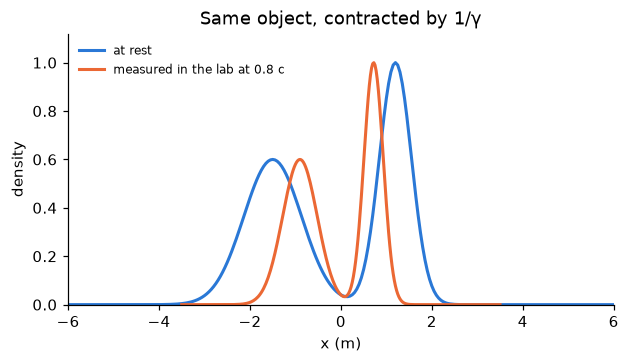

In [27]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(x_rest, shape, color=BLUE, lw=2, label="at rest")
ax.plot(measured.x, measured, color=ORANGE, lw=2, label="measured in the lab at 0.8 c")
ax.legend(loc="upper left", frameon=False, fontsize=8)
ax.set(xlabel="x (m)", ylabel="density", xlim=(-6, 6), ylim=(0, 1.12))
ax.set_title("Same object, contracted by 1/γ")  # noqa: RUF001 (Lorentz factor)
plt.show()

## 10. Save and reload

`rf.encode()` stores the binding as ordinary attributes, so framed arrays round-trip through
Zarr or netCDF with any xarray backend; `rf.decode()` restores and validates it.

In [28]:
image.rf.encode().to_dataset().to_zarr(workdir / "image.zarr", mode="w", consolidated=False)
restored = xr.open_zarr(workdir / "image.zarr", consolidated=False).section.rf.decode()
print(
    "same placement after the round trip:",
    restored.rf.coordinate_transform == image.rf.coordinate_transform,
)

same placement after the round trip: True


## Where it stands

xarrayrf is early and unreleased. It builds on xarray's custom-index machinery; a few operations
need small fixes to xarray that we maintain as a patch series for upstream submission (this
notebook runs with them). Known gaps are tracked openly, and geographic longitude/latitude and
celestial coordinates are next on the design list. Pixel-free grids, declared slice thickness,
anatomical reformatting and anonymous frames are in place.

**Try it**

```sh
git clone https://github.com/matthiasschabel/xarrayrf && cd xarrayrf
uv sync --extra dev --group patched --group docs
uv run --group patched --group docs --with jupyterlab jupyter lab examples/xarrayrf_tour.ipynb
```

More detail: the [README](../README.md), the [interface reference](../docs/core_interface.md) and
the [design](../docs/design.md).